# Data Cleaning — From Messy to Model-Ready

## The Most Underrated Skill in ML

Models don't fail because the math is wrong.
They fail because the data is wrong.

> *"Garbage in, garbage out" — every ML practitioner ever*

Professional data scientists spend **50-80% of their time** on this.
The goal of this notebook: make you fast and systematic at it.

## The Cleaning Checklist

| Step | What You're Looking For |
|---|---|
| 1 | **Audit** — understand the data before touching it |
| 2 | **Missing values** — detect, understand, decide |
| 3 | **Missing strategy** — drop vs fill vs flag vs model |
| 4 | **Outliers** — detect (IQR, Z-score), decide (keep/cap/remove) |
| 5 | **Type errors** — strings that should be numbers, dates as strings |
| 6 | **Categorical inconsistencies** — typos, case, whitespace |
| 7 | **Distribution problems** — skew, scale, zeros |
| 8 | **Pipeline** — wrap it all in reusable, leak-proof code |

## Dataset

We'll use a realistic synthetic version of the Kaggle House Prices dataset
throughout this notebook — the same data you'll clean for `regression_kaggle.ipynb`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 110)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Build a realistic messy dataset ──────────────────────────────────────────
n = 500

# True signal
qual    = np.random.randint(3, 11, n)
area    = np.random.normal(1500, 400, n).clip(300, 5000)
yr      = np.random.randint(1950, 2023, n)
garage  = np.random.choice([0,1,2,3], n, p=[0.05,0.20,0.60,0.15])
bsmt    = np.random.normal(900, 300, n).clip(0, 3000)

price = (area*80 + qual*8000 + (yr-1950)*350 + garage*5000 + bsmt*30
        + np.random.normal(0, 15000, n)).clip(50000, 750000).round(-3)

neighborhoods = np.random.choice(
    ['NAmes','CollgCr','OldTown','Edwards','Somerst','NridgHt','Gilbert','Sawyer'],
    n, p=[0.15,0.15,0.10,0.10,0.12,0.12,0.13,0.13]
)
bldg_types = np.random.choice(['1Fam','TwnhsE','Duplex','2fmCon'], n, p=[0.72,0.16,0.06,0.06])

df_raw = pd.DataFrame({
    'Id':           np.arange(1, n+1),
    'GrLivArea':    area.round(0),
    'OverallQual':  qual,
    'YearBuilt':    yr,
    'GarageCars':   garage.astype(float),
    'TotalBsmtSF':  bsmt.round(0),
    'Neighborhood': neighborhoods,
    'BldgType':     bldg_types,
    'SalePrice':    price,
})

# Inject realistic messiness
idx = np.random.permutation(n)

# Missing values
df_raw.loc[idx[:40],  'GrLivArea']   = np.nan
df_raw.loc[idx[40:55],'TotalBsmtSF'] = np.nan
df_raw.loc[idx[55:65],'GarageCars']  = np.nan

# Wrong types
df_raw['YearBuilt'] = df_raw['YearBuilt'].astype(str)  # year as string
df_raw['GrLivArea'] = df_raw['GrLivArea'].astype(object)  # allow mixed types
df_raw.loc[idx[:5],  'GrLivArea'] = '?'              # string in numeric col
df_raw.loc[idx[5:10],'GrLivArea'] = 'N/A'

# Outliers (real outliers, not just high values)
outlier_idx = idx[:8].tolist()
df_raw.loc[outlier_idx, 'GrLivArea'] = np.random.uniform(8000, 15000, 8).round(0)

# Categorical inconsistencies
noisy_nbhd = df_raw['Neighborhood'].copy()
noise_mask = idx[:20]
noisy_nbhd.iloc[noise_mask[:5]]  = noisy_nbhd.iloc[noise_mask[:5]].str.lower()
noisy_nbhd.iloc[noise_mask[5:10]] = noisy_nbhd.iloc[noise_mask[5:10]].str.upper()
noisy_nbhd.iloc[noise_mask[10:15]] = ' ' + noisy_nbhd.iloc[noise_mask[10:15]]
noisy_nbhd.iloc[noise_mask[15:20]] = noisy_nbhd.iloc[noise_mask[15:20]] + ' '
df_raw['Neighborhood'] = noisy_nbhd

# Duplicate rows
dup_rows = df_raw.iloc[idx[:5]].copy()
df_raw = pd.concat([df_raw, dup_rows], ignore_index=True)

print(f"Dataset created: {df_raw.shape} rows x cols")
print("This is what you'd get from a real Kaggle download.")


Dataset created: (505, 9) rows x cols
This is what you'd get from a real Kaggle download.


---
## Section 1 — The Cleaning Audit

### Never Clean What You Don't Understand

Before touching a single value, answer these questions:

1. How many rows and columns?
2. What type is each column? Did Pandas infer correctly?
3. How many missing values? Which columns? What pattern?
4. What's the distribution of numeric columns? Any impossible values?
5. Are there duplicates?
6. Do categorical columns have consistent values?

This audit takes 10 minutes and saves hours of downstream debugging.


In [2]:
df = df_raw.copy()
print("=" * 65)
print("  CLEANING AUDIT")
print("=" * 65)

# 1. Shape
print()
print(f"1. Shape: {df.shape[0]} rows, {df.shape[1]} cols")

# 2. Dtypes — wrong types are a red flag
print()
print("2. Data types:")
print(df.dtypes.to_frame('dtype').assign(
    nunique=df.nunique(),
    sample=df.iloc[0]
))

# 3. Missing values — count AND percentage
print()
print("3. Missing values:")
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'count': miss, 'pct': miss_pct}).query('count > 0')
print(miss_df)

# 4. Numeric summary — look for impossible values, skew
print()
print("4. Numeric summary:")
# Only truly numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(df[num_cols].describe().round(1))

# 5. Duplicates
n_dupes = df.duplicated().sum()
print()
print(f"5. Duplicate rows: {n_dupes}")
if n_dupes > 0:
    print(df[df.duplicated(keep=False)].head(4))

# 6. Categorical cardinality & top values
print()
print("6. Categorical columns:")
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    vc = df[col].value_counts()
    print(f"  {col}: {df[col].nunique()} unique  |  top: {dict(list(vc.items())[:4])}")

print()
print("=" * 65)
print("  FINDINGS TO FIX:")
print("  - YearBuilt is object (should be int)")
print("  - GrLivArea has '?' and 'N/A' strings (non-numeric)")
print("  - GrLivArea, TotalBsmtSF, GarageCars have missing values")
print("  - GrLivArea has outliers (8000-15000 sqft)")
print("  - Neighborhood has case/whitespace inconsistencies")
print("  - 5 duplicate rows")
print("=" * 65)


  CLEANING AUDIT

1. Shape: 505 rows, 9 cols

2. Data types:
                dtype  nunique    sample
Id              int64      500         1
GrLivArea      object      412   1161.00
OverallQual     int64        8         9
YearBuilt         str       73      1981
GarageCars    float64        4      2.00
TotalBsmtSF   float64      392    707.00
Neighborhood      str       24   Somerst
BldgType          str        4    Duplex
SalePrice     float64      161 180000.00

3. Missing values:
             count  pct
GrLivArea       30 5.90
GarageCars      10 2.00
TotalBsmtSF     15 3.00

4. Numeric summary:
          Id  OverallQual  GarageCars  TotalBsmtSF  SalePrice
count 505.00       505.00      495.00       490.00     505.00
mean  250.70         6.50        1.80       921.00  221002.00
std   144.60         2.30        0.70       295.20   41075.40
min     1.00         3.00        0.00        24.00  102000.00
25%   126.00         5.00        1.00       725.20  195000.00
50%   250.00        

/var/folders/q1/9498s9914m31_cnj__snl5xm0000gn/T/ipykernel_60340/3763466025.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


---
## Section 2 — Handling Missing Values

### The Decision Tree for Missing Data

```
Is it missing?
    |
    v
How much is missing per column?
    > 60-70%  -->  drop the column (usually)
    30-60%    -->  drop OR model imputation + missingness flag
    < 30%     -->  impute
    |
    v
WHY is it missing?
    MCAR (Missing Completely At Random)  -->  simple imputation is fine
    MAR  (Missing At Random)             -->  conditional imputation
    MNAR (Missing Not At Random)         -->  add "was_missing" flag feature!
    |
    v
What's the column type + distribution?
    numeric, low skew   -->  mean
    numeric, high skew  -->  median (more robust to outliers)
    categorical         -->  mode, or a dedicated 'Unknown' category
    ordered/time        -->  forward fill
    fancy               -->  KNN imputation, model-based imputation
```

### The Leakage Warning

**Always fit imputation statistics on training data only.**

```python
# WRONG: fit on all data (test data contaminates train statistics)
fill_val = df['GrLivArea'].median()

# RIGHT: fit on train, apply to both
fill_val = X_train['GrLivArea'].median()
X_train['GrLivArea'] = X_train['GrLivArea'].fillna(fill_val)
X_test['GrLivArea'] = X_test['GrLivArea'].fillna(fill_val)
```


In [3]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

df = df_raw.copy()

print("=== Step 1: Fix Type Errors First (before imputation) ===")
print()

# Convert GrLivArea to numeric — coerce bad strings to NaN
df['GrLivArea'] = pd.to_numeric(df['GrLivArea'], errors='coerce')
# Convert YearBuilt from string to int
df['YearBuilt'] = pd.to_numeric(df['YearBuilt'], errors='coerce').astype('Int64')

print(f"GrLivArea dtype:  {df['GrLivArea'].dtype}   missing: {df['GrLivArea'].isnull().sum()}")
print(f"YearBuilt dtype:  {df['YearBuilt'].dtype}   missing: {df['YearBuilt'].isnull().sum()}")
print()

print("=== Step 2: Missing Value Analysis ===")
print()

def missing_report(df):
    miss  = df.isnull().sum()
    total = len(df)
    report = (pd.DataFrame({'missing': miss, 'pct': (miss/total*100).round(1)})
              .query('missing > 0')
              .sort_values('pct', ascending=False))
    return report

print(missing_report(df))
print()

print("=== Step 3: Imputation Strategies ===")
print()

# Add "was_missing" flags BEFORE imputing
# This preserves the information that a value was absent
flag_cols = ['GrLivArea', 'TotalBsmtSF', 'GarageCars']
for col in flag_cols:
    df[f'{col}_was_missing'] = df[col].isnull().astype(int)

print("Missingness flags added:")
for col in flag_cols:
    flag_col = f'{col}_was_missing'
    print(f"  {flag_col}: {df[flag_col].sum()} flagged rows")
print()

# Impute each column with appropriate strategy
# GrLivArea: skewed distribution -> use median
area_median = df['GrLivArea'].median()
df['GrLivArea'] = df['GrLivArea'].fillna(area_median)
print(f"GrLivArea: filled {df['GrLivArea_was_missing'].sum()} with median={area_median:.0f}")

# TotalBsmtSF: 0 is a valid value (no basement), missing = likely 0
df['TotalBsmtSF'] = df['TotalBsmtSF'].fillna(0)
print("TotalBsmtSF: filled with 0 (no basement)")

# GarageCars: 0 = no garage, missing = likely no garage
df['GarageCars'] = df['GarageCars'].fillna(0)
print("GarageCars: filled with 0 (no garage)")
print()

print("=== sklearn SimpleImputer (production approach) ===")
print()

# In a real pipeline you'd use this inside a Pipeline + ColumnTransformer
# It handles fit/transform split correctly (no leakage)
num_cols = ['GrLivArea', 'TotalBsmtSF', 'GarageCars', 'OverallQual']
imputer  = SimpleImputer(strategy='median')

# Simulate train/test split
idx_split = np.arange(len(df))
tr_idx, te_idx = train_test_split(idx_split, test_size=0.2, random_state=42)

X_tr = df.iloc[tr_idx][num_cols].copy()
X_te = df.iloc[te_idx][num_cols].copy()

# Introduce some missing into the copies
X_tr.loc[X_tr.index[:5], 'GrLivArea'] = np.nan
X_te.loc[X_te.index[:3], 'GrLivArea'] = np.nan

X_tr_imp = imputer.fit_transform(X_tr)   # fit on train
X_te_imp = imputer.transform(X_te)       # transform test with SAME statistics

print("  Imputer statistics (from train):")
for col, stat in zip(num_cols, imputer.statistics_):
    print(f"    {col}: {stat:.1f}")
print(f"  X_tr after impute: {X_tr_imp.shape}  missing: {np.isnan(X_tr_imp).sum()}")
print(f"  X_te after impute: {X_te_imp.shape}  missing: {np.isnan(X_te_imp).sum()}")


=== Step 1: Fix Type Errors First (before imputation) ===

GrLivArea dtype:  float64   missing: 32
YearBuilt dtype:  Int64   missing: 0

=== Step 2: Missing Value Analysis ===

             missing  pct
GrLivArea         32 6.30
TotalBsmtSF       15 3.00
GarageCars        10 2.00

=== Step 3: Imputation Strategies ===

Missingness flags added:
  GrLivArea_was_missing: 32 flagged rows
  TotalBsmtSF_was_missing: 15 flagged rows
  GarageCars_was_missing: 10 flagged rows

GrLivArea: filled 32 with median=1506
TotalBsmtSF: filled with 0 (no basement)
GarageCars: filled with 0 (no garage)

=== sklearn SimpleImputer (production approach) ===

  Imputer statistics (from train):
    GrLivArea: 1506.0
    TotalBsmtSF: 893.5
    GarageCars: 2.0
    OverallQual: 6.0
  X_tr after impute: (404, 4)  missing: 0
  X_te after impute: (101, 4)  missing: 0


---
## Section 3 — Outlier Detection & Handling

### Two Standard Detection Methods

**IQR (Interquartile Range)** — robust, distribution-agnostic
```python
Q1, Q3  = df['col'].quantile([0.25, 0.75])
IQR     = Q3 - Q1
lower   = Q1 - 1.5 * IQR
upper   = Q3 + 1.5 * IQR
outliers = df[(df['col'] < lower) | (df['col'] > upper)]
```

**Z-score** — assumes Normal distribution
```python
z = np.abs(stats.zscore(df['col'].dropna()))
outliers = df[z > 3]
```

### Three Handling Strategies

| Strategy | When to use |
|---|---|
| **Remove** | Outlier is clearly a data entry error (1.5M sqft house) |
| **Winsorize (cap)** | Outlier might be real but extreme — cap at percentile |
| **Log transform** | Outlier is a true extreme value — compress the scale |

**For competition ML:** rarely remove — every row has signal. Winsorize or transform.


=== Outlier Detection: IQR Method ===

  GrLivArea      : bounds=[476, 2544]   outliers=18 (3.6%)
  TotalBsmtSF    : bounds=[102, 1714]   outliers=18 (3.6%)
  SalePrice      : bounds=[114000, 330000]   outliers=1 (0.2%)

=== Outlier Detection: Z-Score Method ===

  GrLivArea      : |z| > 3  ->  13 outliers (2.6%)
  SalePrice      : |z| > 3  ->  0 outliers (0.0%)

=== Visualize: Before and After ===



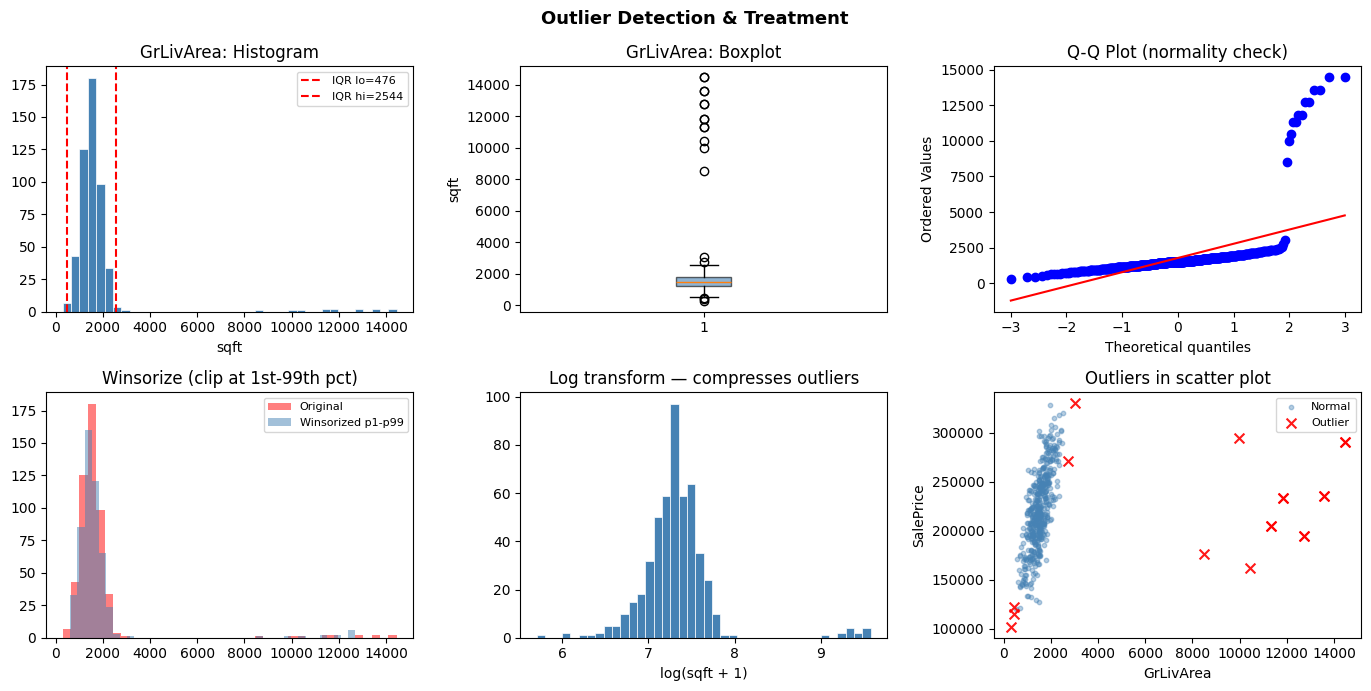


=== Applying the Fix: Winsorization ===

  GrLivArea: clipped 12 values to [617, 12706]
  TotalBsmtSF: clipped 6 values to [0, 1568]

Note: we keep all rows — for competition ML, every sample has value.
Only remove outliers if they're clear data entry errors.


In [4]:
from scipy import stats as scipy_stats

# Work with the cleaned df from section 2
df_s3 = df.copy()

print("=== Outlier Detection: IQR Method ===")
print()

def iqr_bounds(series, factor=1.5):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - factor * IQR, Q3 + factor * IQR

for col in ['GrLivArea', 'TotalBsmtSF', 'SalePrice']:
    lo, hi   = iqr_bounds(df_s3[col].dropna())
    n_out    = ((df_s3[col] < lo) | (df_s3[col] > hi)).sum()
    pct      = n_out / len(df_s3) * 100
    print(f"  {col:15}: bounds=[{lo:.0f}, {hi:.0f}]   outliers={n_out} ({pct:.1f}%)")
print()

print("=== Outlier Detection: Z-Score Method ===")
print()

for col in ['GrLivArea', 'SalePrice']:
    clean   = df_s3[col].dropna()
    z       = np.abs(scipy_stats.zscore(clean))
    n_out   = (z > 3).sum()
    pct     = n_out / len(clean) * 100
    print(f"  {col:15}: |z| > 3  ->  {n_out} outliers ({pct:.1f}%)")
print()

print("=== Visualize: Before and After ===")
print()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Outlier Detection & Treatment", fontsize=13, fontweight='bold')

col       = 'GrLivArea'
clean_col = df_s3[col].dropna()
lo, hi    = iqr_bounds(clean_col, factor=1.5)
lo_w, hi_w = np.percentile(clean_col, 1), np.percentile(clean_col, 99)

# Row 1: Distribution views
axes[0,0].hist(clean_col, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0,0].axvline(lo, color='red',    linestyle='--', label=f'IQR lo={lo:.0f}')
axes[0,0].axvline(hi, color='red',    linestyle='--', label=f'IQR hi={hi:.0f}')
axes[0,0].set_title(f'{col}: Histogram')
axes[0,0].legend(fontsize=8)
axes[0,0].set_xlabel('sqft')

axes[0,1].boxplot(clean_col.values, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0,1].set_title(f'{col}: Boxplot')
axes[0,1].set_ylabel('sqft')

# Q-Q plot (checks normality)
scipy_stats.probplot(clean_col.values, dist="norm", plot=axes[0,2])
axes[0,2].set_title('Q-Q Plot (normality check)')

# Row 2: Winsorization effect
winsorized = clean_col.clip(lower=lo_w, upper=hi_w)
log_orig   = np.log1p(clean_col)
log_wins   = np.log1p(winsorized)

axes[1,0].hist(clean_col, bins=40, alpha=0.5, color='red', label='Original')
axes[1,0].hist(winsorized, bins=40, alpha=0.5, color='steelblue', label='Winsorized p1-p99')
axes[1,0].set_title('Winsorize (clip at 1st-99th pct)')
axes[1,0].legend(fontsize=8)

axes[1,1].hist(log_orig.values, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1,1].set_title('Log transform — compresses outliers')
axes[1,1].set_xlabel('log(sqft + 1)')

# Show price vs area with outlier coloring
outlier_mask = (df_s3[col] < lo) | (df_s3[col] > hi)
normal_mask  = ~outlier_mask & df_s3[col].notna()
axes[1,2].scatter(df_s3.loc[normal_mask, col],  df_s3.loc[normal_mask,  'SalePrice'],
                  alpha=0.4, s=10, color='steelblue', label='Normal')
axes[1,2].scatter(df_s3.loc[outlier_mask, col], df_s3.loc[outlier_mask, 'SalePrice'],
                  alpha=0.9, s=50, color='red', marker='x', label='Outlier')
axes[1,2].set_title('Outliers in scatter plot')
axes[1,2].set_xlabel(col)
axes[1,2].set_ylabel('SalePrice')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/outliers.png', dpi=100, bbox_inches='tight')
plt.show()
print()

print("=== Applying the Fix: Winsorization ===")
print()
# Winsorize at 1st and 99th percentile — clips but keeps all rows
numeric_cols_to_winsorize = ['GrLivArea', 'TotalBsmtSF']
for col in numeric_cols_to_winsorize:
    clean = df_s3[col].dropna()
    lo_p1  = np.percentile(clean, 1)
    hi_p99 = np.percentile(clean, 99)
    n_clipped = ((df_s3[col] < lo_p1) | (df_s3[col] > hi_p99)).sum()
    df_s3[col] = df_s3[col].clip(lower=lo_p1, upper=hi_p99)
    print(f"  {col}: clipped {n_clipped} values to [{lo_p1:.0f}, {hi_p99:.0f}]")

print()
print("Note: we keep all rows — for competition ML, every sample has value.")
print("Only remove outliers if they're clear data entry errors.")


---
## Section 4 — Categorical Inconsistencies

### The Most Common Categorical Problems

```
'NAmes'   'names'   'NAMES'   ' NAmes'   'NAmes '   # Same value, 5 forms
'1Fam'    '1FAM'    '1fam'                          # Building type
'Y'       'Yes'     'yes'     '1'         True      # Boolean
```

### Standard Cleaning Steps for Categoricals

```python
# 1. Strip whitespace
df['col'] = df['col'].str.strip()

# 2. Normalize case (usually lowercase or title case)
df['col'] = df['col'].str.lower()

# 3. Check what's left
df['col'].value_counts()

# 4. Fix any remaining typos with .replace()
df['col'] = df['col'].replace({'naemes': 'naames', ...})
```


In [5]:
df_s4 = df.copy()

print("=== Categorical Audit ===")
print()

# Show the mess
print("Raw Neighborhood unique values (first 15):")
print(sorted(df_s4['Neighborhood'].unique())[:15])
print(f"  Total unique: {df_s4['Neighborhood'].nunique()}")
print()

print("=== Fixing: strip + title-case ===")
print()

for col in ['Neighborhood', 'BldgType']:
    before = df_s4[col].nunique()
    df_s4[col] = df_s4[col].str.strip().str.strip()
    # For Neighborhood we want original casing (proper nouns), so use strip only
    # then fix case to match the canonical form
    after  = df_s4[col].nunique()
    print(f"  {col}: {before} unique -> {after} unique after strip")

# Some are still wrong due to case — normalize to title case, then map back
canonical_neighborhoods = {
    'names':  'NAmes',
    'naames': 'NAmes',
    'NAMES':  'NAmes',
    'oldtown': 'OldTown',
    'OLDTOWN': 'OldTown',
    'collgcr': 'CollgCr',
    'COLLGCR': 'CollgCr',
    'edwards': 'Edwards',
    'EDWARDS': 'Edwards',
    'somerst': 'Somerst',
    'SOMERST': 'Somerst',
    'nridght': 'NridgHt',
    'NRIDGHT': 'NridgHt',
    'gilbert': 'Gilbert',
    'GILBERT': 'Gilbert',
    'sawyer':  'Sawyer',
    'SAWYER':  'Sawyer',
}

# Fix case issues: if lowercase version matches a canonical value, fix it
def fix_neighborhood(val):
    if pd.isna(val):
        return val
    val_stripped = val.strip()
    return canonical_neighborhoods.get(val_stripped.lower(), val_stripped)

df_s4['Neighborhood'] = df_s4['Neighborhood'].apply(fix_neighborhood)

print()
print("After fix:")
print(f"  Neighborhood unique: {df_s4['Neighborhood'].nunique()}")
print(f"  Values: {sorted(df_s4['Neighborhood'].unique())}")
print()

# Validate: check value_counts for anything unexpected
print("Value counts after cleaning:")
print(df_s4['Neighborhood'].value_counts())
print()

print("=== Handling Duplicates ===")
print()
n_dupes = df_s4.duplicated().sum()
print(f"  Duplicate rows: {n_dupes}")

df_s4 = df_s4.drop_duplicates().reset_index(drop=True)
print(f"  After drop_duplicates: {df_s4.shape[0]} rows")
print()

# What if duplicated on a subset? (same Id but different values = data quality issue)
id_dupes = df_s4.duplicated(subset=['Id']).sum()
print(f"  Duplicate Ids: {id_dupes}  (should be 0 after full dedup)")


=== Categorical Audit ===

Raw Neighborhood unique values (first 15):
[' CollgCr', ' Gilbert', ' NAmes', ' NridgHt', ' Somerst', 'COLLGCR', 'CollgCr', 'CollgCr ', 'Edwards', 'Gilbert', 'Gilbert ', 'NAMES', 'NAmes', 'NAmes ', 'NridgHt']
  Total unique: 24

=== Fixing: strip + title-case ===

  Neighborhood: 24 unique -> 15 unique after strip
  BldgType: 4 unique -> 4 unique after strip

After fix:
  Neighborhood unique: 8
  Values: ['CollgCr', 'Edwards', 'Gilbert', 'NAmes', 'NridgHt', 'OldTown', 'Sawyer', 'Somerst']

Value counts after cleaning:
Neighborhood
CollgCr    84
NAmes      73
Gilbert    71
NridgHt    70
Somerst    62
Sawyer     58
OldTown    45
Edwards    42
Name: count, dtype: int64

=== Handling Duplicates ===

  Duplicate rows: 5
  After drop_duplicates: 500 rows

  Duplicate Ids: 0  (should be 0 after full dedup)


---
## Section 5 — Feature Distributions & Transforms

### Why Distributions Matter

Linear models and distance-based models (Ridge, Lasso, KNN, SVM, neural nets)
assume — or benefit from — features being roughly Normal and on similar scales.

Tree-based models (RandomForest, XGBoost, LightGBM) don't care about distributions.

### The Three Fixes

**Problem: Skewed distribution**
```python
# Right-skewed (long tail right) -- SalePrice, GrLivArea, income
df['log_price'] = np.log1p(df['SalePrice'])   # log1p handles zeros

# Or Box-Cox (automatically finds best power transform)
from scipy.stats import boxcox
transformed, lambda_ = boxcox(df['col'] + 1)
```

**Problem: Different scales**
```python
# StandardScaler: mean=0, std=1  (for linear models, PCA, neural nets)
# MinMaxScaler:   [0, 1]          (for distance-based, if no outliers)
# RobustScaler:   uses median/IQR (if outliers present)
```

**Problem: Zero-inflated**  
(many zeros with a tail of positive values — garage area, lot features)
```python
df['has_garage']  = (df['GarageArea'] > 0).astype(int)  # binary flag
df['log_garage']  = np.log1p(df['GarageArea'])           # compress the tail
```


=== Skewness Audit ===

  GrLivArea      : skew=+7.10  kurtosis=55.04 <- SKEWED
  TotalBsmtSF    : skew=-0.40  kurtosis=0.53
  OverallQual    : skew=-0.01  kurtosis=-1.23
  SalePrice      : skew=+0.01  kurtosis=-0.25

  Rule of thumb: |skew| > 1  -> consider log transform
                 |skew| > 0.5 -> at least check a histogram



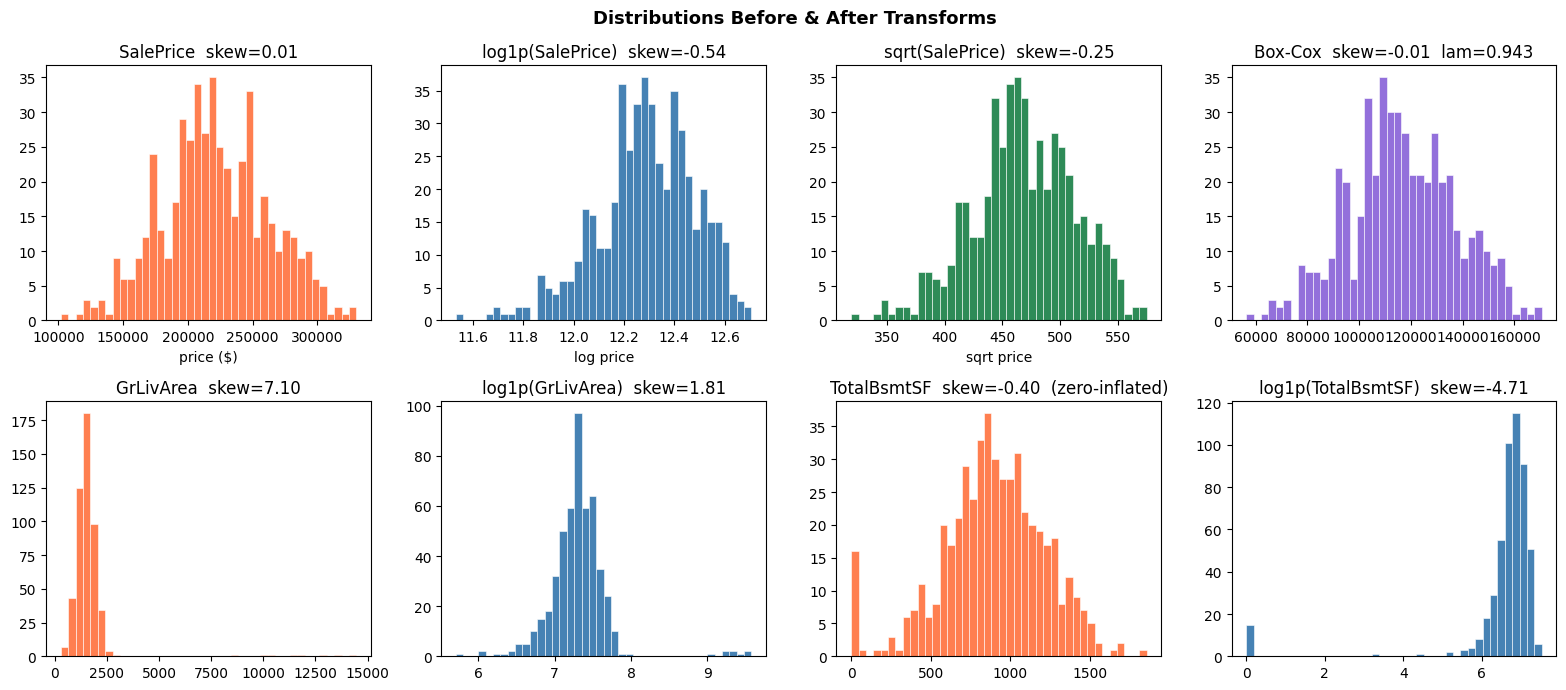

=== Applying Transforms ===

New columns added:
       log_SalePrice  log_GrLivArea  log_TotalBsmtSF  has_basement  HouseAge
count         500.00         500.00           500.00        500.00    500.00
mean           12.29           7.31             6.56          0.97     38.85
std             0.19           0.39             1.22          0.17     20.84
min            11.53           5.71             0.00          0.00      2.00
25%            12.18           7.12             6.56          1.00     20.00
50%            12.29           7.32             6.80          1.00     39.00
75%            12.43           7.47             7.01          1.00     58.00
max            12.71           9.58             7.53          1.00     74.00


In [6]:
from scipy import stats as scipy_stats

df_s5 = df_s4.copy() if 'df_s4' in dir() else df_s3.copy()

print("=== Skewness Audit ===")
print()

num_cols = ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'SalePrice']
for col in num_cols:
    skew = df_s5[col].dropna().skew()
    kurt = df_s5[col].dropna().kurtosis()
    flag = " <- SKEWED" if abs(skew) > 1 else ""
    print(f"  {col:15}: skew={skew:+.2f}  kurtosis={kurt:.2f}{flag}")
print()
print("  Rule of thumb: |skew| > 1  -> consider log transform")
print("                 |skew| > 0.5 -> at least check a histogram")
print()

# Visualize distributions and transforms
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Distributions Before & After Transforms", fontsize=13, fontweight='bold')

col     = 'SalePrice'
prices  = df_s5[col].dropna()

# Original
axes[0,0].hist(prices, bins=40, color='coral', edgecolor='white', linewidth=0.4)
axes[0,0].set_title(col + '  skew=' + f'{prices.skew():.2f}')
axes[0,0].set_xlabel('price ($)')

# Log transform
log_p = np.log1p(prices)
axes[0,1].hist(log_p, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0,1].set_title('log1p(' + col + ')  skew=' + f'{log_p.skew():.2f}')
axes[0,1].set_xlabel('log price')

# Square root
sqrt_p = np.sqrt(prices)
axes[0,2].hist(sqrt_p, bins=40, color='seagreen', edgecolor='white', linewidth=0.4)
axes[0,2].set_title('sqrt(' + col + ')  skew=' + f'{sqrt_p.skew():.2f}')
axes[0,2].set_xlabel('sqrt price')

# Box-Cox
bc_p, lam = scipy_stats.boxcox(prices.values + 1)
axes[0,3].hist(bc_p, bins=40, color='mediumpurple', edgecolor='white', linewidth=0.4)
axes[0,3].set_title(f'Box-Cox  skew={pd.Series(bc_p).skew():.2f}  lam={lam:.3f}')

# GrLivArea
area = df_s5['GrLivArea'].dropna()
axes[1,0].hist(area, bins=40, color='coral', edgecolor='white', linewidth=0.4)
axes[1,0].set_title('GrLivArea  skew=' + f'{area.skew():.2f}')

log_a = np.log1p(area)
axes[1,1].hist(log_a, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1,1].set_title('log1p(GrLivArea)  skew=' + f'{log_a.skew():.2f}')

# TotalBsmtSF: zero-inflated
bsmt = df_s5['TotalBsmtSF'].dropna()
axes[1,2].hist(bsmt, bins=40, color='coral', edgecolor='white', linewidth=0.4)
axes[1,2].set_title('TotalBsmtSF  skew=' + f'{bsmt.skew():.2f}  (zero-inflated)')

log_b = np.log1p(bsmt)
axes[1,3].hist(log_b, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1,3].set_title('log1p(TotalBsmtSF)  skew=' + f'{log_b.skew():.2f}')

plt.tight_layout()
plt.savefig('/tmp/distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print("=== Applying Transforms ===")
print()

df_s5['log_SalePrice']   = np.log1p(df_s5['SalePrice'])
df_s5['log_GrLivArea']   = np.log1p(df_s5['GrLivArea'])
df_s5['log_TotalBsmtSF'] = np.log1p(df_s5['TotalBsmtSF'])
df_s5['has_basement']    = (df_s5['TotalBsmtSF'] > 0).astype(int)
df_s5['HouseAge']        = (2024 - df_s5['YearBuilt'].astype(float)).clip(0, 100)

print("New columns added:")
new_cols = ['log_SalePrice', 'log_GrLivArea', 'log_TotalBsmtSF', 'has_basement', 'HouseAge']
print(df_s5[new_cols].describe().round(3))


---
## Section 6 — The Reusable Cleaning Pipeline

### Why You Need a Pipeline

**The problem with ad-hoc cleaning:**

```python
# You clean the training set
df_train['GrLivArea'] = df_train['GrLivArea'].fillna(df_train['GrLivArea'].median())
df_train['Neighborhood'] = df_train['Neighborhood'].str.strip()

# Now you get test data...
# Do you remember every step? In the right order?
# Did you use train statistics for imputation?
```

**The solution:** a function (or sklearn Pipeline) that applies all cleaning steps
in a deterministic, reproducible order, using statistics learned from training data only.

### sklearn `Pipeline` + `ColumnTransformer`

This is the professional approach — the same pattern used in production ML systems:

```python
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
    ]), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encode', OrdinalEncoder()),
    ]), categorical_cols),
])
```


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score

# Start from raw data
df_pipe = df_raw.copy()

# ── Step 1: Manual pre-cleaning (type fixes that sklearn can't do) ────────────
print("=== Step 1: Type Fixes ===")

# These are the transforms that don't fit neatly in a sklearn pipeline
df_pipe['GrLivArea']   = pd.to_numeric(df_pipe['GrLivArea'], errors='coerce')
df_pipe['YearBuilt']   = pd.to_numeric(df_pipe['YearBuilt'], errors='coerce')
df_pipe['HouseAge']    = 2024 - df_pipe['YearBuilt']
df_pipe['Neighborhood']= df_pipe['Neighborhood'].str.strip()
df_pipe = df_pipe.drop_duplicates().reset_index(drop=True)

print(f"  Rows after dedup: {len(df_pipe)}")
print(f"  Type errors fixed: GrLivArea={df_pipe['GrLivArea'].dtype}, YearBuilt={df_pipe['YearBuilt'].dtype}")
print()

# ── Step 2: Train/test split BEFORE any fitting ───────────────────────────────
print("=== Step 2: Train/Test Split ===")

feature_cols = ['GrLivArea', 'OverallQual', 'HouseAge', 'GarageCars', 'TotalBsmtSF']
cat_cols_raw = ['Neighborhood', 'BldgType']
target_col   = 'SalePrice'

X  = df_pipe[feature_cols + cat_cols_raw]
y  = np.log1p(df_pipe[target_col])   # log-transform target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"  X_train: {X_train.shape}   X_test: {X_test.shape}")
print()

# ── Step 3: Build the pipeline ────────────────────────────────────────────────
print("=== Step 3: sklearn Pipeline ===")
print()

# Numeric preprocessing
num_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

# Categorical preprocessing
cat_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_transformer, feature_cols),
    ('cat', cat_transformer, cat_cols_raw),
])

# Full pipeline: preprocessing + model
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10.0)),
])

# ── Step 4: Fit on train only ─────────────────────────────────────────────────
print("=== Step 4: Fit & Evaluate ===")
print()

cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='r2')
full_pipeline.fit(X_train, y_train)
test_r2 = full_pipeline.score(X_test, y_test)

print(f"  CV R2:   {cv_scores.round(3)}  mean={cv_scores.mean():.4f}  std={cv_scores.std():.4f}")
print(f"  Test R2: {test_r2:.4f}")
print()

# ── Step 5: Inspect what the pipeline learned ────────────────────────────────
print("=== Step 5: Inspect Pipeline Stats (no leakage check) ===")
print()

imp_stats = full_pipeline['preprocessor'].transformers_[0][1]['impute'].statistics_
scale_mean = full_pipeline['preprocessor'].transformers_[0][1]['scale'].mean_
print("  Imputation medians (from training set):")
for col, stat in zip(feature_cols, imp_stats):
    print(f"    {col:15}: {stat:.2f}")
print()
print("  StandardScaler means (from training set):")
for col, mean in zip(feature_cols, scale_mean):
    print(f"    {col:15}: {mean:.2f}")
print()

print("  Predicting on new data:")
X_new = pd.DataFrame({
    'GrLivArea':    [1400.0, np.nan],   # one missing value
    'OverallQual':  [7, 8],
    'HouseAge':     [20, 5],
    'GarageCars':   [2, 2],
    'TotalBsmtSF':  [900.0, np.nan],   # one missing value
    'Neighborhood': ['NAmes', 'UNKNOWN_NBHD'],  # one unknown category
    'BldgType':     ['1Fam', '1Fam'],
})
log_pred = full_pipeline.predict(X_new)
pred_price = np.expm1(log_pred)
print(f"  Predicted prices: {pred_price.round(-3)}")
print("  (Missing values and unknown categories handled automatically by pipeline)")


=== Step 1: Type Fixes ===
  Rows after dedup: 500
  Type errors fixed: GrLivArea=float64, YearBuilt=int64

=== Step 2: Train/Test Split ===
  X_train: (400, 7)   X_test: (100, 7)

=== Step 3: sklearn Pipeline ===

=== Step 4: Fit & Evaluate ===

  CV R2:   [0.288 0.28  0.179 0.325 0.347]  mean=0.2840  std=0.0578
  Test R2: 0.2103

=== Step 5: Inspect Pipeline Stats (no leakage check) ===

  Imputation medians (from training set):
    GrLivArea      : 1507.00
    OverallQual    : 6.00
    HouseAge       : 38.00
    GarageCars     : 2.00
    TotalBsmtSF    : 920.00

  StandardScaler means (from training set):
    GrLivArea      : 1672.51
    OverallQual    : 6.59
    HouseAge       : 38.79
    GarageCars     : 1.85
    TotalBsmtSF    : 927.51

  Predicting on new data:
  Predicted prices: [223000. 238000.]
  (Missing values and unknown categories handled automatically by pipeline)


---
## Summary — Data Cleaning

### The Cleaning Checklist

```python
# 1. AUDIT (always first)
df.shape
df.dtypes
df.describe()
df.isnull().sum()
df.duplicated().sum()
df['cat_col'].value_counts()

# 2. TYPES
df['col'] = pd.to_numeric(df['col'], errors='coerce')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['year'].astype(int)

# 3. MISSING
df['col_was_missing'] = df['col'].isnull().astype(int)  # flag first!
df['col'].fillna(df['col'].median())   # numeric, skewed
df['col'].fillna(df['col'].mean())     # numeric, symmetric
df['col'].fillna('Unknown')            # categorical
df['col'].fillna(0)                    # zero = meaningful (no garage)

# 4. OUTLIERS
Q1, Q3 = df['col'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df['col'] = df['col'].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)  # winsorize
# OR:
df = df[np.abs(scipy.stats.zscore(df['col'])) < 3]        # remove

# 5. CATEGORICALS
df['col'] = df['col'].str.strip().str.lower()
df['col'] = df['col'].replace({'typo': 'correct'})

# 6. DUPLICATES
df = df.drop_duplicates().reset_index(drop=True)

# 7. DISTRIBUTIONS
df['log_price'] = np.log1p(df['SalePrice'])   # right-skewed
df['has_feat']  = (df['col'] > 0).astype(int) # zero-inflated

# 8. PIPELINE (production-ready)
preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]),         numeric_cols),
    ('cat', Pipeline([('impute', SimpleImputer(fill_value='Missing')),
                      ('encode', OrdinalEncoder())]),        cat_cols),
])
```

### The Non-Negotiable Rules

1. **Audit before touching** — understand what you have
2. **Flag before imputing** — preserve the missingness signal
3. **Split before fitting** — never compute statistics on test data
4. **Keep raw data** — never overwrite the source file
5. **Document every decision** — future you will thank present you

### Next Notebook
`eda.ipynb` — systematic exploratory data analysis with visualizations
